# Micro Proyecto 1 — Generación de Música con LSTM
Compositor seleccionado: **Ludwig van Beethoven**

In [6]:
# ── Bandera de entorno ─────────────────────────────────────────────────────
# False → corre en local con los paths relativos del repo
# True  → corre en Google Colab con Google Drive montado
COLAB = False

if COLAB:
    
    from google.colab import drive
    drive.mount('/content/drive')

    !pip install pretty_midi

    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'


In [2]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygame
import time
import torch
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
torch.manual_seed(42)

/opt/anaconda3/envs/master/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.11.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


## 1. Leer los archivos MIDI de Beethoven

In [3]:
if COLAB:
    # Google Drive: MyDrive/MASTER NLP_2/Microproyecto_1/data/music_artist/beeth
    DATA_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/beeth'
else:
    # Local: path relativo al notebook
    DATA_PATH = './data/music_artist/beeth'

midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')
for i, f in enumerate(midi_files):
    print(f'  [{i}] {os.path.basename(f)}')

Archivos encontrados: 29
  [0] appass_1.mid
  [1] appass_2.mid
  [2] appass_3.mid
  [3] beethoven_hammerklavier_1.mid
  [4] beethoven_hammerklavier_2.mid
  [5] beethoven_hammerklavier_3.mid
  [6] beethoven_hammerklavier_4.mid
  [7] beethoven_les_adieux_1.mid
  [8] beethoven_les_adieux_2.mid
  [9] beethoven_les_adieux_3.mid
  [10] beethoven_opus10_1.mid
  [11] beethoven_opus10_2.mid
  [12] beethoven_opus10_3.mid
  [13] beethoven_opus22_1.mid
  [14] beethoven_opus22_2.mid
  [15] beethoven_opus22_3.mid
  [16] beethoven_opus22_4.mid
  [17] beethoven_opus90_1.mid
  [18] beethoven_opus90_2.mid
  [19] elise.mid
  [20] mond_1.mid
  [21] mond_2.mid
  [22] mond_3.mid
  [23] pathetique_1.mid
  [24] pathetique_2.mid
  [25] pathetique_3.mid
  [26] waldstein_1.mid
  [27] waldstein_2.mid
  [28] waldstein_3.mid


## 2. Escuchar un archivo

In [4]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')

if not COLAB:
    play_midi(midi_files[27], seconds=5)

Reproduciendo: waldstein_2.mid (5s)...
Listo.


## 3. Explorar un archivo

In [16]:
pm = pretty_midi.PrettyMIDI(midi_files[0])

print(f'Archivo: {os.path.basename(midi_files[0])}')
print(f'Duración: {pm.get_end_time():.2f} segundos')
print(f'Número de instrumentos: {len(pm.instruments)}')

for i, instrument in enumerate(pm.instruments):
    instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
    print(f'  Instrumento {i}: {instrument_name} — {len(instrument.notes)} notas')

Archivo: appass_1.mid
Duración: 558.90 segundos
Número de instrumentos: 2
  Instrumento 0: Acoustic Grand Piano — 3207 notas
  Instrumento 1: Acoustic Grand Piano — 3170 notas


In [17]:
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
notes = sorted(instrument.notes, key=lambda x: x.start)

print(f'Instrumento: {instrument_name}')
print(f'\nPrimeras 10 notas (características de entrenamiento):')
print(f'{"pitch":>8} {"step":>10} {"duration":>10} {"velocity":>10}')

prev_start = None
for note in notes[:10]:
    step = note.start - prev_start if prev_start is not None else 0.0
    duration = note.end - note.start
    print(f'{note.pitch:>8} {step:>10.3f} {duration:>10.3f} {note.velocity:>10}')
    prev_start = note.start

Instrumento: Acoustic Grand Piano

Primeras 10 notas (características de entrenamiento):
   pitch       step   duration   velocity
      60      0.000      0.519         35
      56      0.519      0.137         31
      53      0.137      1.669         28
      56      1.669      0.477         35
      60      0.477      0.107         30
      65      0.107      0.528         35
      68      0.528      0.468         35
      72      0.468      0.102         30
      77      0.102      0.559         35
      65      0.567      0.556         33


## 4. Extraer las características de todos los archivos

Por cada nota extraemos:
- **pitch**: nota musical (categórica)
- **step**: tiempo desde la nota anterior (start_actual - start_anterior)
- **duration**: duración de la nota (end - start)
- **velocity**: velocidad de la nota (numérica)

In [18]:
TARGET_INSTRUMENT = 'Acoustic Grand Piano'

def extract_notes(instrument):
    notes = sorted(instrument.notes, key=lambda x: x.start)
    rows = []
    prev_start = None
    for note in notes:
        duration = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({'pitch': note.pitch, 'step': step, 'duration': duration, 'velocity': note.velocity})
        prev_start = note.start
    return rows

all_notes = []
sequences = []  # lista de DataFrames, uno por secuencia (instrumento x archivo)

for mid, f in enumerate(midi_files):
    pm = pretty_midi.PrettyMIDI(f)
    for i, instrument in enumerate(pm.instruments):
        inst_name = pretty_midi.program_to_instrument_name(instrument.program)
        if inst_name != TARGET_INSTRUMENT:
            continue  # solo usar Acoustic Grand Piano
        notes = extract_notes(instrument)
        seq_df = pd.DataFrame(notes)
        sequences.append(seq_df)
        all_notes.extend(notes)
        if mid < 3:
            print(f'{os.path.basename(f)} — instrumento {i} ({inst_name}): {len(notes)} notas')

df = pd.DataFrame(all_notes)
print(f'\nTotal de secuencias: {len(sequences)}')
print(f'Total de notas: {len(df)}')
df.head(10)

appass_1.mid — instrumento 0 (Acoustic Grand Piano): 3207 notas
appass_1.mid — instrumento 1 (Acoustic Grand Piano): 3170 notas
appass_2.mid — instrumento 0 (Acoustic Grand Piano): 1128 notas
appass_2.mid — instrumento 1 (Acoustic Grand Piano): 853 notas
appass_3.mid — instrumento 0 (Acoustic Grand Piano): 3742 notas
appass_3.mid — instrumento 1 (Acoustic Grand Piano): 3481 notas

Total de secuencias: 47
Total de notas: 84785


,pitch,step,duration,velocity
0,60,0.000000,0.518640,35
1,56,0.518640,0.136599,31
2,53,0.136599,1.669347,28
3,56,1.669347,0.477331,35
4,60,0.477331,0.107427,30
5,65,0.107427,0.528293,35
6,68,0.528293,0.468093,35
7,72,0.468093,0.101550,30
8,77,0.101550,0.558752,35
9,65,0.566917,0.556449,33


## 5. Análisis Exploratorio de Datos (EDA)

In [19]:
# --- 5.1 Instrumentos por archivo ---
print(f'{"Archivo":<35} {"N° inst":>7}  Instrumentos')
print('-' * 70)

instrument_types = []
for f in midi_files:
    pm_f = pretty_midi.PrettyMIDI(f)
    names = [pretty_midi.program_to_instrument_name(inst.program) for inst in pm_f.instruments]
    instrument_types.extend(names)
    print(f'{os.path.basename(f):<35} {len(pm_f.instruments):>7}  {", ".join(names)}')

print(f'\nTipos de instrumento únicos: {set(instrument_types)}')
print(f'Total de archivos: {len(midi_files)}')
print(f'Total de secuencias (archivos x instrumentos): {len(sequences)}')

Archivo                             N° inst  Instrumentos
----------------------------------------------------------------------
appass_1.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_2.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_3.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_1.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_2.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_3.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_4.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_1.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_2.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_3.mid                2  Acoustic Grand Piano, Acoustic Gra

In [20]:
# --- 5.2 Notas totales y por secuencia ---
notes_per_seq = [len(s) for s in sequences]

print(f'Total de notas en el dataset:      {len(df):,}')
print(f'Notas únicas (pitch distintos):    {df["pitch"].nunique()}  (pitch {df["pitch"].min()} – {df["pitch"].max()})')
print(f'\nNotas por secuencia:')
print(f'  Mínimo:   {min(notes_per_seq):,}')
print(f'  Máximo:   {max(notes_per_seq):,}')
print(f'  Promedio: {np.mean(notes_per_seq):,.1f}')

durations_sec = [pretty_midi.PrettyMIDI(f).get_end_time() for f in midi_files]
print(f'\nDuración total acumulada: {sum(durations_sec)/60:.1f} minutos')

Total de notas en el dataset:      84,785
Notas únicas (pitch distintos):    78  (pitch 24 – 101)

Notas por secuencia:
  Mínimo:   118
  Máximo:   4,499
  Promedio: 1,803.9

Duración total acumulada: 182.4 minutos


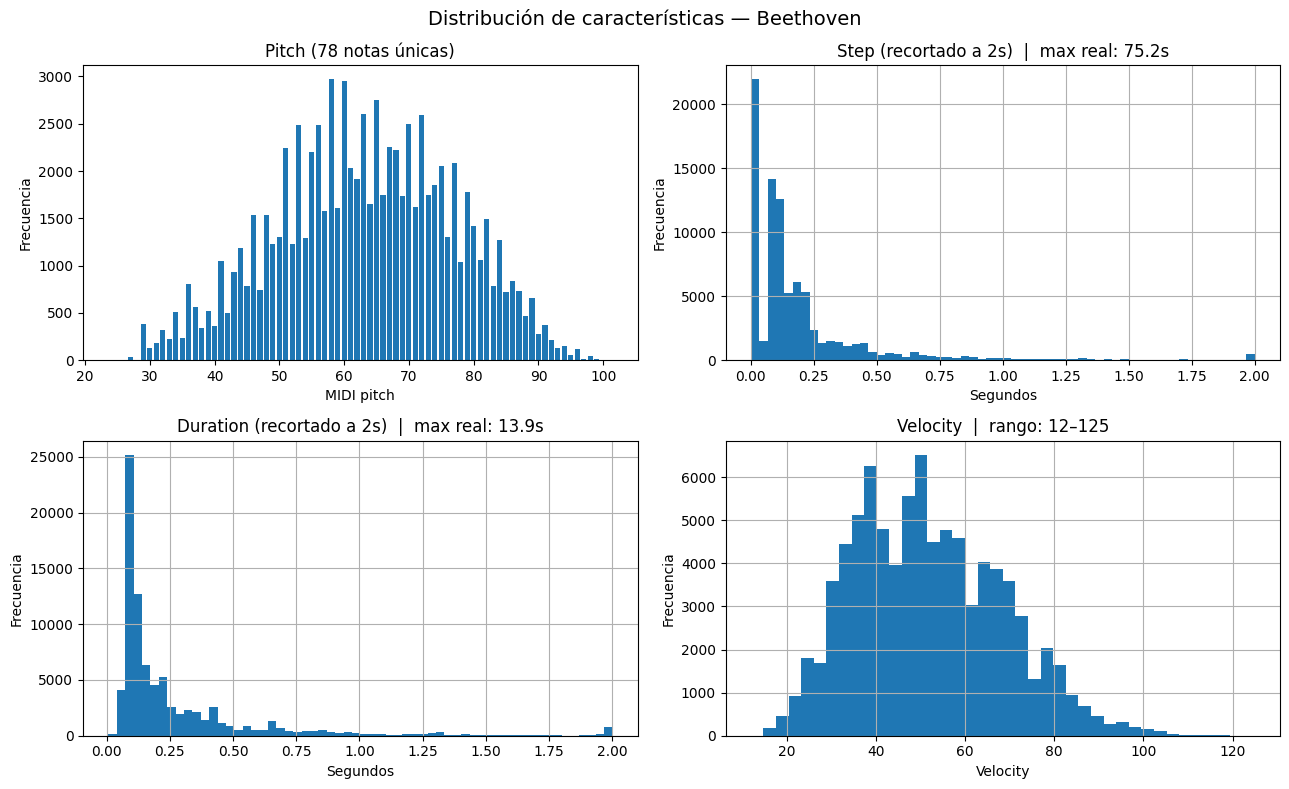


Estadísticas descriptivas:
           pitch       step   duration   velocity
count  84785.000  84785.000  84785.000  84785.000
mean      63.193      0.200      0.286     51.866
std       13.787      0.448      0.416     16.574
min       24.000      0.000      0.007     12.000
25%       53.000      0.000      0.096     39.000
50%       63.000      0.108      0.140     50.000
75%       73.000      0.213      0.323     63.000
max      101.000     75.246     13.944    125.000


In [21]:
# --- 5.3 Distribución de las 4 características ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribución de características — Beethoven', fontsize=14)

pitch_counts = df['pitch'].value_counts().sort_index()
axes[0, 0].bar(pitch_counts.index, pitch_counts.values, width=0.8)
axes[0, 0].set_title(f'Pitch ({df["pitch"].nunique()} notas únicas)')
axes[0, 0].set_xlabel('MIDI pitch')
axes[0, 0].set_ylabel('Frecuencia')

df['step'].clip(0, 2).hist(ax=axes[0, 1], bins=60, edgecolor='none')
axes[0, 1].set_title(f'Step (recortado a 2s)  |  max real: {df["step"].max():.1f}s')
axes[0, 1].set_xlabel('Segundos')
axes[0, 1].set_ylabel('Frecuencia')

df['duration'].clip(0, 2).hist(ax=axes[1, 0], bins=60, edgecolor='none')
axes[1, 0].set_title(f'Duration (recortado a 2s)  |  max real: {df["duration"].max():.1f}s')
axes[1, 0].set_xlabel('Segundos')
axes[1, 0].set_ylabel('Frecuencia')

df['velocity'].hist(ax=axes[1, 1], bins=40, edgecolor='none')
axes[1, 1].set_title(f'Velocity  |  rango: {df["velocity"].min()}–{df["velocity"].max()}')
axes[1, 1].set_xlabel('Velocity')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas:')
print(df.describe().round(3))

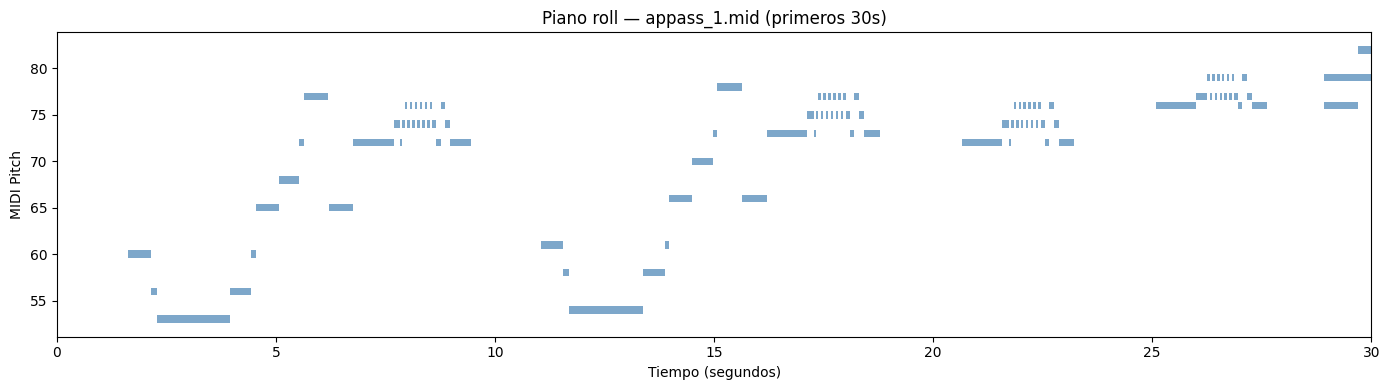

In [22]:
# --- 5.4 Piano roll de una composición de ejemplo ---
pm_example = pretty_midi.PrettyMIDI(midi_files[0])
notes_example = sorted(pm_example.instruments[0].notes, key=lambda x: x.start)

cutoff = 30
notes_plot = [n for n in notes_example if n.start < cutoff]

fig, ax = plt.subplots(figsize=(14, 4))
for note in notes_plot:
    ax.barh(note.pitch, note.end - note.start, left=note.start, height=0.8, color='steelblue', alpha=0.7)

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('MIDI Pitch')
ax.set_title(f'Piano roll — {os.path.basename(midi_files[0])} (primeros {cutoff}s)')
ax.set_xlim(0, cutoff)
plt.tight_layout()
plt.show()

## 6. Preparación del dataset para entrenamiento

In [23]:
# --- 6.1 Split train / test al nivel de secuencia ---
# Se hace el split por secuencia completa para evaluar en canciones que el modelo nunca vio.
n_sequences = len(sequences)
idx_all = np.random.permutation(n_sequences)
split = int(n_sequences * 0.9)  # 90/10: más datos de entrenamiento

train_seqs = [sequences[i] for i in idx_all[:split]]
test_seqs  = [sequences[i] for i in idx_all[split:]]

print(f'Total de secuencias: {n_sequences}')
print(f'  Train: {len(train_seqs)} secuencias  ({sum(len(s) for s in train_seqs):,} notas)')
print(f'  Test:  {len(test_seqs)} secuencias  ({sum(len(s) for s in test_seqs):,} notas)')

Total de secuencias: 47
  Train: 42 secuencias  (77,282 notas)
  Test:  5 secuencias  (7,503 notas)


In [24]:
# --- 6.2 Normalización ---
# pitch  → se deja como entero (0-127) para usarlo en un Embedding
# step, duration, velocity → MinMaxScaler ajustado SOLO con datos de train
#
# IMPORTANTE: step y duration tienen outliers extremos (max ~185s, pausas entre canciones).
# Clipeamos a percentil 99 antes de normalizar para que el scaler no aplaste todo el rango.

STEP_CLIP     = pd.concat(train_seqs)['step'].quantile(0.99)
DURATION_CLIP = pd.concat(train_seqs)['duration'].quantile(0.99)
print(f'Clip step al percentil 99:     {STEP_CLIP:.4f} s')
print(f'Clip duration al percentil 99: {DURATION_CLIP:.4f} s')

scaler = MinMaxScaler()
train_clipped = pd.concat(train_seqs).copy()
train_clipped['step']     = train_clipped['step'].clip(0, STEP_CLIP)
train_clipped['duration'] = train_clipped['duration'].clip(0, DURATION_CLIP)
scaler.fit(train_clipped[['step', 'duration', 'velocity']])

def normalize_seq(seq_df, scaler, step_clip, duration_clip):
    """Devuelve un array (N, 4): [pitch_int, step_norm, duration_norm, velocity_norm]"""
    arr = seq_df.copy()
    arr['step']     = arr['step'].clip(0, step_clip)
    arr['duration'] = arr['duration'].clip(0, duration_clip)
    arr[['step', 'duration', 'velocity']] = scaler.transform(arr[['step', 'duration', 'velocity']])
    return arr.values

train_arrays = [normalize_seq(s, scaler, STEP_CLIP, DURATION_CLIP) for s in train_seqs]
test_arrays  = [normalize_seq(s, scaler, STEP_CLIP, DURATION_CLIP) for s in test_seqs]

print('\nEjemplo de una nota normalizada [pitch, step_norm, duration_norm, velocity_norm]:'  )
print(f'  {train_arrays[0][0]}')

Clip step al percentil 99:     1.5415 s
Clip duration al percentil 99: 1.7870 s

Ejemplo de una nota normalizada [pitch, step_norm, duration_norm, velocity_norm]:
  [4.60000000e+01 0.00000000e+00 3.85448423e-02 2.12389381e-01]


In [25]:
# --- 6.3 DataLoader ---
BLOCK_SIZE = 32   # 32 notas de contexto (~2-4 compases): captura frases musicales más largas
BATCH_SIZE = 64

class MusicDataLoader:
    def __init__(self, sequences, block_size):
        self.block_size = block_size
        self.sequences  = [torch.tensor(s, dtype=torch.float32) for s in sequences]

        self.indices = []
        for seq_idx, seq in enumerate(self.sequences):
            for start in range(len(seq) - block_size):
                self.indices.append((seq_idx, start))

        self.order    = np.random.permutation(len(self.indices))
        self.curr_pos = 0

    def get_batch(self, batch_size):
        batch_idx = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_idx)

        if len(batch_idx) < batch_size:
            self.curr_pos = 0
            self.order = np.random.permutation(len(self.indices))
            if len(batch_idx) == 0:
                batch_idx = self.order[:batch_size]
                self.curr_pos = batch_size

        xs, ys = [], []
        for i in batch_idx:
            seq_idx, start = self.indices[i]
            seq = self.sequences[seq_idx]
            xs.append(seq[start : start + self.block_size])
            ys.append(seq[start + self.block_size])

        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self):
        return len(self.indices)


train_loader = MusicDataLoader(train_arrays, block_size=BLOCK_SIZE)
test_loader  = MusicDataLoader(test_arrays,  block_size=BLOCK_SIZE)

print(f'Block size (contexto): {BLOCK_SIZE} notas')
print(f'Batch size:            {BATCH_SIZE}')
print(f'Ventanas de entrenamiento: {train_loader.n_examples:,}')
print(f'Ventanas de test:          {test_loader.n_examples:,}')

x_sample, y_sample = train_loader.get_batch(BATCH_SIZE)
print(f'\nForma de un lote:')
print(f'  x: {tuple(x_sample.shape)}  -> (batch, contexto, features)')
print(f'  y: {tuple(y_sample.shape)}  -> (batch, features)')
print(f'\nRango de step normalizado en un batch: [{x_sample[:,:,1].min():.3f}, {x_sample[:,:,1].max():.3f}]')

Block size (contexto): 32 notas
Batch size:            64
Ventanas de entrenamiento: 75,938
Ventanas de test:          7,343

Forma de un lote:
  x: (64, 32, 4)  -> (batch, contexto, features)
  y: (64, 4)  -> (batch, features)

Rango de step normalizado en un batch: [0.000, 1.000]


## 7. Modelo LSTM

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

VOCAB_SIZE  = 128   # notas MIDI posibles (0-127)
EMBED_DIM   = 64    # dimensión del embedding de pitch (subido de 16 → 64)
HIDDEN_SIZE = 512   # tamaño del estado oculto del LSTM (subido de 256 → 512)
NUM_LAYERS  = 3     # capas LSTM apiladas (subido de 2 → 3)
DROPOUT     = 0.5   # dropout entre capas LSTM

class MusicLSTM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding para pitch (variable categórica, 128 valores posibles)
        self.pitch_embedding = torch.nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        # LSTM: recibe [embed_pitch(64) + step(1) + duration(1) + velocity(1)] = 67 features
        self.lstm = torch.nn.LSTM(
            input_size  = EMBED_DIM + 3,
            hidden_size = HIDDEN_SIZE,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT
        )
        # Cabeza pitch → 128 logits (CrossEntropy)
        self.head_pitch    = torch.nn.Linear(HIDDEN_SIZE, VOCAB_SIZE)
        # Cabezas numéricas → 1 valor cada una (MAE)
        self.head_step     = torch.nn.Linear(HIDDEN_SIZE, 1)
        self.head_duration = torch.nn.Linear(HIDDEN_SIZE, 1)
        self.head_velocity = torch.nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        # x: (batch, block_size, 4) — col 0=pitch(int), cols 1-3=numéricas normalizadas
        pitch_idx = x[:, :, 0].long()                               # (batch, block_size)
        numerics  = x[:, :, 1:]                                     # (batch, block_size, 3)
        pitch_emb = self.pitch_embedding(pitch_idx)                 # (batch, block_size, 64)
        lstm_in   = torch.cat([pitch_emb, numerics], dim=-1)       # (batch, block_size, 67)
        lstm_out, _ = self.lstm(lstm_in)                            # (batch, block_size, 512)
        last_hidden = lstm_out[:, -1, :]                            # (batch, 512)
        pitch_logits  = self.head_pitch(last_hidden)                # (batch, 128)
        step_pred     = self.head_step(last_hidden).squeeze(1)      # (batch,)
        duration_pred = self.head_duration(last_hidden).squeeze(1)
        velocity_pred = self.head_velocity(last_hidden).squeeze(1)
        return pitch_logits, step_pred, duration_pred, velocity_pred


model = MusicLSTM().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros totales: {n_params:,}')
print(model)

Dispositivo: cuda
Parámetros totales: 5,467,779
MusicLSTM(
  (pitch_embedding): Embedding(128, 64)
  (lstm): LSTM(67, 512, num_layers=3, batch_first=True, dropout=0.5)
  (head_pitch): Linear(in_features=512, out_features=128, bias=True)
  (head_step): Linear(in_features=512, out_features=1, bias=True)
  (head_duration): Linear(in_features=512, out_features=1, bias=True)
  (head_velocity): Linear(in_features=512, out_features=1, bias=True)
)


## 8. Entrenamiento

In [27]:
# --- 8.1 Función de pérdida compuesta ---
# pitch      → CrossEntropy (variable categórica)
# step, duration, velocity → MAE (variables continuas normalizadas en [0,1])
# Las 3 features continuas tienen el mismo peso (10) ya que todas están en la misma escala.

ce_loss  = torch.nn.CrossEntropyLoss()
mae_loss = torch.nn.L1Loss()

LAMBDA_STEP     = 10.0
LAMBDA_DURATION = 10.0
LAMBDA_VELOCITY = 10.0  # igualado a step y duration (antes era 5.0)

def composed_loss(pitch_logits, step_pred, duration_pred, velocity_pred, y):
    """y: (batch, 4) — [pitch(int), step_norm, duration_norm, velocity_norm]"""
    l_pitch    = ce_loss(pitch_logits, y[:, 0].long())
    l_step     = mae_loss(step_pred,     y[:, 1])
    l_duration = mae_loss(duration_pred, y[:, 2])
    l_velocity = mae_loss(velocity_pred, y[:, 3])
    total = l_pitch + LAMBDA_STEP * l_step + LAMBDA_DURATION * l_duration + LAMBDA_VELOCITY * l_velocity
    return total, l_pitch, l_step, l_duration, l_velocity


@torch.no_grad()
def estimate_loss(model, train_loader, test_loader, eval_iters=10):
    model.eval()
    results = {}
    for name, loader in [('train', train_loader), ('test', test_loader)]:
        losses = []
        for _ in range(eval_iters):
            x, y = loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)
            loss, *_ = composed_loss(*model(x), y)
            losses.append(loss.item())
        results[name] = sum(losses) / eval_iters
    model.train()
    return results['train'], results['test']

In [28]:
LR           = 0.001
WEIGHT_DECAY = 0.001
EPOCHS       = 50
steps_per_epoch = train_loader.n_examples // BATCH_SIZE
MAX_STEPS       = EPOCHS * steps_per_epoch

print(f'Pasos por época:  {steps_per_epoch}')
print(f'Total de pasos:   {MAX_STEPS}')

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: reduce LR a la mitad si el test loss no mejora en 5 evaluaciones (~500 pasos)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

train_losses_log = []
test_losses_log  = []

model.train()
for step in range(MAX_STEPS):
    x, y = train_loader.get_batch(BATCH_SIZE)
    x, y = x.to(device), y.to(device)

    loss, *_ = composed_loss(*model(x), y)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (step + 1) % 100 == 0 or step == 0 or step == MAX_STEPS - 1:
        train_loss, test_loss = estimate_loss(model, train_loader, test_loader)
        train_losses_log.append(train_loss)
        test_losses_log.append(test_loss)
        scheduler.step(test_loss)
        print(f'Step {step+1:5d}/{MAX_STEPS} — Train loss: {train_loss:.4f}  Test loss: {test_loss:.4f}')

Pasos por época:  1186
Total de pasos:   59300
Step     1/59300 — Train loss: 9.4783  Test loss: 9.4368
Step   100/59300 — Train loss: 6.8331  Test loss: 6.6076
Step   200/59300 — Train loss: 6.3301  Test loss: 6.5210
Step   300/59300 — Train loss: 6.3941  Test loss: 6.6735
Step   400/59300 — Train loss: 6.6797  Test loss: 6.6995
Step   500/59300 — Train loss: 6.2861  Test loss: 6.6385
Step   600/59300 — Train loss: 6.5031  Test loss: 6.7191
Step   700/59300 — Train loss: 6.4129  Test loss: 6.4935
Step   800/59300 — Train loss: 6.4815  Test loss: 6.6408
Step   900/59300 — Train loss: 6.4928  Test loss: 6.4967
Step  1000/59300 — Train loss: 6.1983  Test loss: 6.5274
Step  1100/59300 — Train loss: 6.2974  Test loss: 6.3980
Step  1200/59300 — Train loss: 6.2071  Test loss: 6.3936
Step  1300/59300 — Train loss: 6.3699  Test loss: 6.4694
Step  1400/59300 — Train loss: 6.2655  Test loss: 6.2624
Step  1500/59300 — Train loss: 6.3322  Test loss: 6.5645
Step  1600/59300 — Train loss: 6.2940  Te

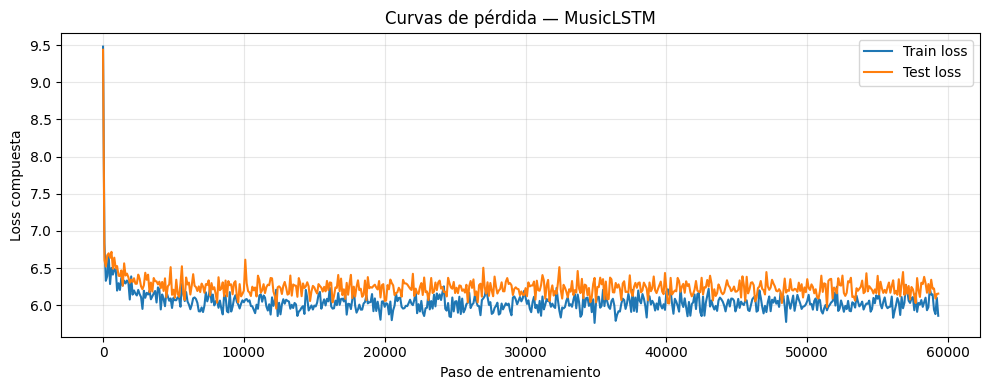

In [29]:
# --- 8.3 Curvas de pérdida ---
steps_logged = ([1] + list(range(100, MAX_STEPS, 100)) + [MAX_STEPS])[:len(train_losses_log)]

plt.figure(figsize=(10, 4))
plt.plot(steps_logged, train_losses_log, label='Train loss')
plt.plot(steps_logged, test_losses_log,  label='Test loss')
plt.xlabel('Paso de entrenamiento')
plt.ylabel('Loss compuesta')
plt.title('Curvas de pérdida — MusicLSTM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Generación y evaluación

In [30]:
@torch.no_grad()
def generate_notes(model, seed_seq, n_notes=200, temperature=1.0):
    """
    Genera n_notes notas a partir de una secuencia semilla del conjunto de test.
    temperature: >1 más variedad, <1 más conservador.
    Retorna un DataFrame con las notas desnormalizadas.
    """
    model.eval()
    context = torch.tensor(seed_seq[-BLOCK_SIZE:], dtype=torch.float32).unsqueeze(0).to(device)

    generated = []
    for _ in range(n_notes):
        pitch_logits, step_pred, duration_pred, velocity_pred = model(context)

        # Muestreo con temperatura para pitch
        probs = torch.softmax(pitch_logits[0] / temperature, dim=-1)
        pitch = torch.multinomial(probs, num_samples=1).item()

        step     = step_pred[0].item()
        duration = duration_pred[0].item()
        velocity = velocity_pred[0].item()

        generated.append([pitch, step, duration, velocity])

        # Deslizar la ventana de contexto
        new_note = torch.tensor([[pitch, step, duration, velocity]], dtype=torch.float32).unsqueeze(0).to(device)
        context  = torch.cat([context[:, 1:, :], new_note], dim=1)

    gen_array = np.array(generated)

    # Desnormalizar step, duration, velocity
    gen_denorm = gen_array.copy()
    gen_denorm[:, 1:] = scaler.inverse_transform(gen_array[:, 1:])

    # Clipear a rangos válidos
    gen_denorm[:, 0] = np.clip(gen_denorm[:, 0], 0, 127).astype(int)
    gen_denorm[:, 1] = np.clip(gen_denorm[:, 1], 0, None)
    gen_denorm[:, 2] = np.clip(gen_denorm[:, 2], 0.01, None)
    gen_denorm[:, 3] = np.clip(gen_denorm[:, 3], 1, 127)

    return pd.DataFrame(gen_denorm, columns=['pitch', 'step', 'duration', 'velocity']).astype(
        {'pitch': int, 'velocity': int}
    )


In [31]:
if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'

os.makedirs(GENERATED_DIR, exist_ok=True)

def notes_to_midi(df_notes, output_path, instrument_name='Acoustic Grand Piano'):
    pm_out   = pretty_midi.PrettyMIDI()
    program  = pretty_midi.instrument_name_to_program(instrument_name)
    inst_out = pretty_midi.Instrument(program=program)
    current_start = 0.0
    for _, row in df_notes.iterrows():
        current_start += float(row['step'])
        note = pretty_midi.Note(
            velocity = int(row['velocity']),
            pitch    = int(row['pitch']),
            start    = current_start,
            end      = current_start + float(row['duration'])
        )
        inst_out.notes.append(note)
    pm_out.instruments.append(inst_out)
    pm_out.write(output_path)

for i, temp in enumerate([0.5, 0.7, 0.9], start=1):
    seed   = test_arrays[i % len(test_arrays)][:BLOCK_SIZE]
    df_gen = generate_notes(model, seed, n_notes=200, temperature=temp)
    path   = os.path.join(GENERATED_DIR, f'beethoven_gen_{i}.mid')
    notes_to_midi(df_gen, path)
    print(f'Guardado: {os.path.basename(path)}')

print(f'\nArchivos MIDI generados en: {GENERATED_DIR}')

if COLAB:
    from google.colab import files
    for i in range(1, 4):
        fpath = os.path.join(GENERATED_DIR, f'beethoven_gen_{i}.mid')
        files.download(fpath)
        print(f'Descargando: {os.path.basename(fpath)}')


Guardado: beethoven_gen_1.mid
Guardado: beethoven_gen_2.mid
Guardado: beethoven_gen_3.mid

Archivos MIDI generados en: /content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_1.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_2.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_3.mid


## 10. Evaluación: generado vs real

In [32]:
# --- 10.1 Cargar archivo generado y secuencia real de referencia ---

# Generado: leer el primer archivo MIDI generado
pm_gen = pretty_midi.PrettyMIDI(os.path.join(GENERATED_DIR, 'beethoven_gen_1.mid'))
notes_gen_raw = sorted(pm_gen.instruments[0].notes, key=lambda n: n.start)

# Reconstruir DataFrame del generado desde el MIDI
rows_gen = []
prev_start = None
for n in notes_gen_raw:
    step = n.start - prev_start if prev_start is not None else 0.0
    rows_gen.append({'pitch': n.pitch, 'step': step, 'duration': n.end - n.start, 'velocity': n.velocity})
    prev_start = n.start
df_gen = pd.DataFrame(rows_gen)

# Real: la secuencia semilla usada para generar (test_seqs[1])
seq_real = test_seqs[1 % len(test_seqs)].reset_index(drop=True)

# Las primeras BLOCK_SIZE notas fueron el contexto (seed) → el modelo generó desde BLOCK_SIZE en adelante
# Comparamos el generado contra las notas reales que "debería haber seguido"
df_real_seed = seq_real.iloc[:BLOCK_SIZE]                        # notas 0-(BLOCK_SIZE-1): contexto dado
df_real_next = seq_real.iloc[BLOCK_SIZE:BLOCK_SIZE + 200]        # notas BLOCK_SIZE+: continuación real
df_real_next = df_real_next.reset_index(drop=True)

print(f'Notas de contexto (seed):          {len(df_real_seed)}')
print(f'Notas reales de referencia ({BLOCK_SIZE}+):  {len(df_real_next)}')
print(f'Notas generadas:                   {len(df_gen)}')
print()
print('Las notas reales de referencia son las que el modelo debería haber "continuado".')
print('El modelo no debe reproducirlas exactamente, sino generar música de estilo similar.\n')

# Estadísticas comparativas
stats = pd.DataFrame({
    'pitch_mean':    [df_gen['pitch'].mean(),    df_real_next['pitch'].mean()],
    'pitch_std':     [df_gen['pitch'].std(),     df_real_next['pitch'].std()],
    'step_mean':     [df_gen['step'].mean(),     df_real_next['step'].mean()],
    'step_std':      [df_gen['step'].std(),      df_real_next['step'].std()],
    'duration_mean': [df_gen['duration'].mean(), df_real_next['duration'].mean()],
    'velocity_mean': [df_gen['velocity'].mean(), df_real_next['velocity'].mean()],
}, index=['Generado', 'Real (ref)']).T.round(4)

print('Comparación estadística (Generado vs continuación real):')
print(stats)

Notas de contexto (seed):          32
Notas reales de referencia (32+):  185
Notas generadas:                   200

Las notas reales de referencia son las que el modelo debería haber "continuado".
El modelo no debe reproducirlas exactamente, sino generar música de estilo similar.

Comparación estadística (Generado vs continuación real):
               Generado  Real (ref)
pitch_mean      64.5300     41.5081
pitch_std       10.1432      6.9775
step_mean        0.1835      1.6374
step_std         0.1184      2.2960
duration_mean    0.2874      3.2277
velocity_mean   38.6200     43.5297


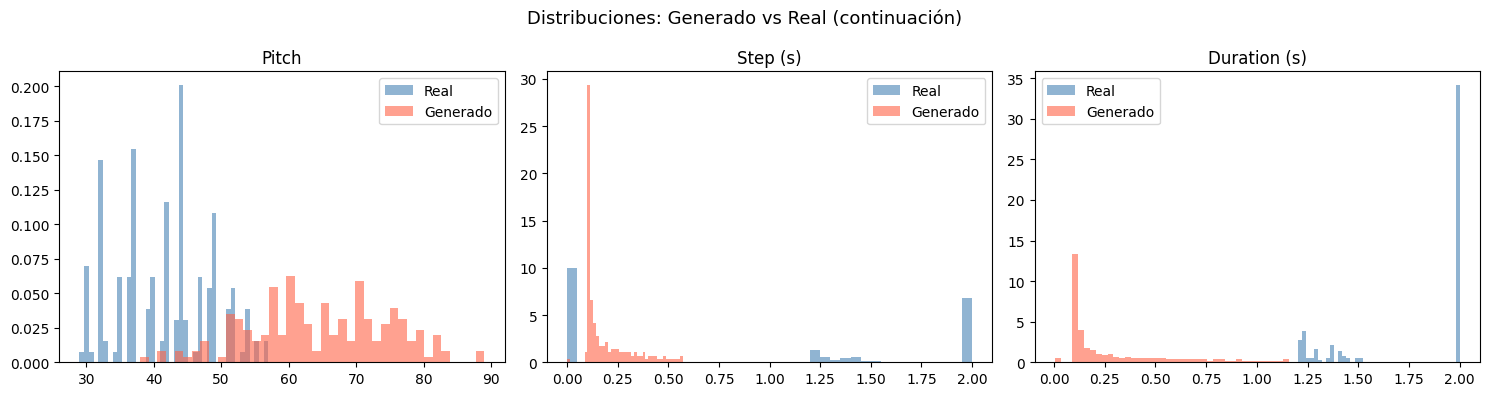

In [33]:
# --- 10.2 Distribuciones generado vs real ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuciones: Generado vs Real (continuación)', fontsize=13)

for ax, col, label, clip_val in [
    (axes[0], 'pitch',    'Pitch',       None),
    (axes[1], 'step',     'Step (s)',    2.0),
    (axes[2], 'duration', 'Duration (s)', 2.0),
]:
    gen_vals  = df_gen[col].clip(0, clip_val)       if clip_val else df_gen[col]
    real_vals = df_real_next[col].clip(0, clip_val) if clip_val else df_real_next[col]
    ax.hist(real_vals, bins=40, alpha=0.6, label='Real',     density=True, color='steelblue')
    ax.hist(gen_vals,  bins=40, alpha=0.6, label='Generado', density=True, color='tomato')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

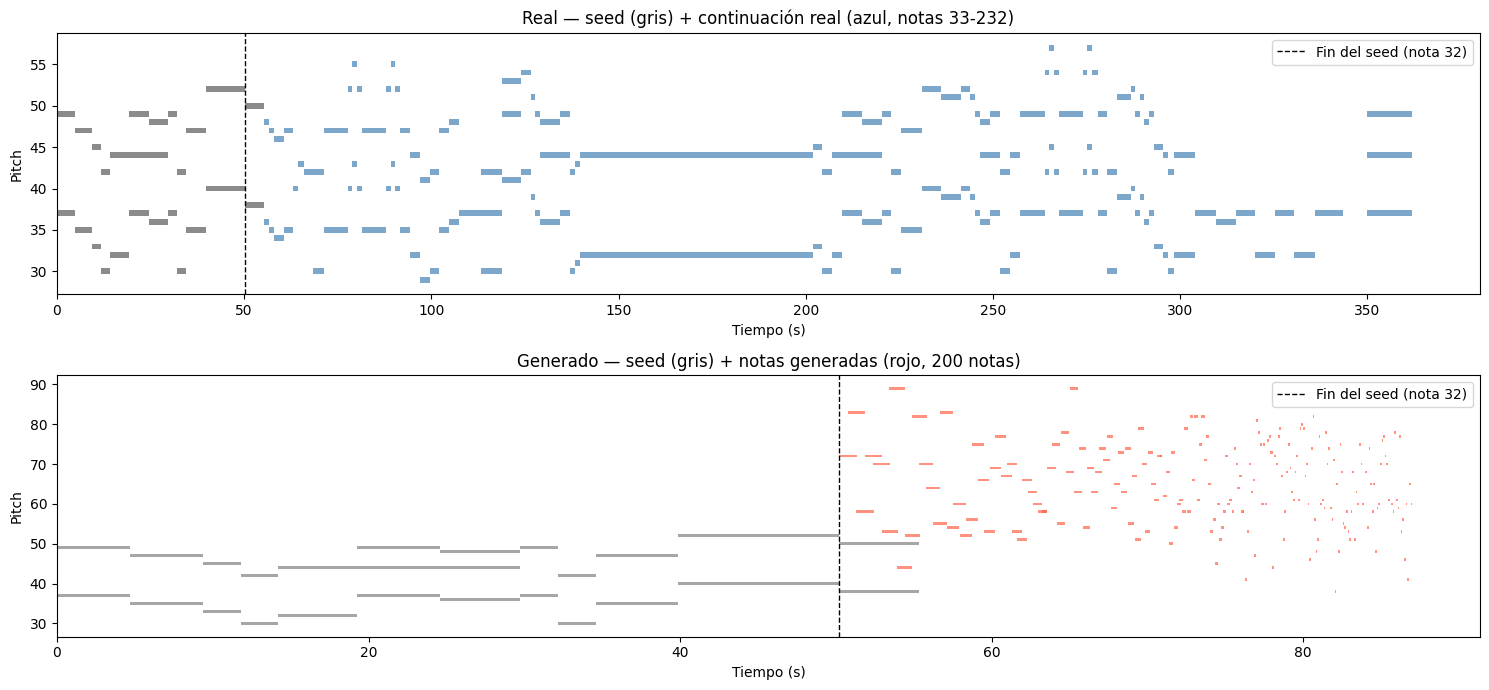

Step promedio real (ref):     1.6374 s
Step promedio generado:       0.1835 s
Ratio (gen/real):             0.11x  ← más rápido


In [34]:
# --- 10.3 Piano roll: seed + generado vs seed + continuación real ---
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

def plot_roll(ax, df, color, offset_t=0.0):
    """Dibuja un piano roll desde un DataFrame con columnas step/duration/pitch."""
    t = offset_t
    for _, row in df.iterrows():
        t += row['step']
        ax.barh(row['pitch'], row['duration'], left=t, height=0.7, color=color, alpha=0.7)
    return t

# Escala de tiempo real del seed (para alinear ambos rolls)
seed_end = df_real_seed['step'].sum()

# Real: seed (gris) + continuación real (azul)
plot_roll(axes[0], df_real_seed, color='gray')
plot_roll(axes[0], df_real_next, color='steelblue', offset_t=seed_end)
axes[0].axvline(seed_end, color='black', linestyle='--', linewidth=1, label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[0].set_title(f'Real — seed (gris) + continuación real (azul, notas {BLOCK_SIZE+1}-{BLOCK_SIZE+200})')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Pitch')
axes[0].legend()

# Generado: seed (gris) + notas generadas (rojo)
plot_roll(axes[0], df_real_seed, color='gray')  # referencia visual
plot_roll(axes[1], df_real_seed, color='gray')
plot_roll(axes[1], df_gen, color='tomato', offset_t=seed_end)
axes[1].axvline(seed_end, color='black', linestyle='--', linewidth=1, label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[1].set_title(f'Generado — seed (gris) + notas generadas (rojo, 200 notas)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Pitch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Step promedio real (ref):     {df_real_next["step"].mean():.4f} s')
print(f'Step promedio generado:       {df_gen["step"].mean():.4f} s')
ratio = df_gen['step'].mean() / df_real_next['step'].mean() if df_real_next['step'].mean() > 0 else float('inf')
print(f'Ratio (gen/real):             {ratio:.2f}x  {"← más rápido" if ratio < 1 else "← más lento" if ratio > 1 else "← igual"}')

In [7]:
# Escuchar una canción generada — cambia el número (1, 2 o 3)
play_midi(os.path.join(GENERATED_DIR, 'beethoven_gen_1.mid'), seconds=15)

Reproduciendo: beethoven_gen_1.mid (15s)...
Listo.
